In [2]:
%%html
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:wght@300;400;500;600;700&display=swap" rel="stylesheet">

<style>
/* markdown + output */
body, .markdown-body, .jp-RenderedHTMLCommon, div.text_cell_render,
.notebook, .notebook * {
  font-family: "Source Serif 4", serif !important;
}

/* code editor (monaco) */
.monaco-editor, .monaco-editor * {
  font-family: "Source Serif 4", serif !important;
}
</style>


We'll use:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `scipy.stats` for statistical functions and probability distributions

In [3]:
# Import all required libraries
import scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import os
from scipy.stats import *
from scipy.stats import norm, t, binom, poisson, expon

In [4]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

---

#### 1. Descriptive Statistics: Boxplot

#### Boxplot?

A **boxplot** (box-and-whisker plot) is a standardized way of displaying the distribution of data based on five key summary statistics:

![Boxplot Anatomy](https://soc.utah.edu/sociology3112/_resources/images/box-plot.gif)

#### Key Components:

1. **Median (Q2)**: The middle value of the dataset (50th percentile)
2. **First Quartile (Q1)**: 25th percentile
3. **Third Quartile (Q3)**: 75th percentile
4. **Interquartile Range (IQR)**: The range between Q1 and Q3 (middle 50% of data)

$$\text{IQR} = Q_3 - Q_1$$

5. **Whiskers**: Lines extending from the box to the smallest and largest values within acceptable range
6. **Outliers**: Data points outside the whiskers (shown as individual dots)

#### Outlier Detection Formula:

$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$

$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$

- **Lower Whisker** = Smallest data point ≥ Lower Bound, minimum / 0th Percentile
- **Upper Whisker** = Largest data point ≤ Upper Bound, maximum / 100th Percentile
- **Outliers** = Any value < Lower Bound OR > Upper Bound [`usually dots`]

#### Use Cases:
- Compare distributions across multiple groups
- Identify skewness and spread
- Detect outliers quickly

---

In [5]:
df = pd.read_excel('data/Values.xlsx')
df.head()

,Values
0,32
1,38
2,128
3,49
4,44


In [6]:
q1 = np.percentile(df.Values, 25)  # First quartile (25th percentile)
q2 = np.percentile(df.Values, 50)  # Median (50th percentile)
q3 = np.percentile(df.Values, 75)  # Third quartile (75th percentile)

# IQR (Interquartile Range)
iqr = q3 - q1


print(f'q1: {q1}')
print(f'q1: {q2}')
print(f'q1: {q3}')
print(f'iqr: {iqr}')

q1: 43.0
q1: 50.0
q1: 56.25
iqr: 13.25


In [7]:
# calculate outlier boundaries
uf = q3 + 1.5 * iqr  # Upper fence (upper bound)
lf = q1 - 1.5 * iqr  # Lower fence (lower bound)

print(f"lf: {lf}")
print(f"uf: {uf}")

lf: 23.125
uf: 76.125


In [8]:
# count how many outliers are above the upper bound
upper_outliers_count = (df.Values > uf).sum()
print(upper_outliers_count)

7


In [9]:
# count how many outliers are below the lower bound
lower_outliers_count = (df.Values < lf).sum()
print(lower_outliers_count)

6


In [10]:
# Find the UPPER WHISKER:
# The upper whisker is the maximum value that is still ≤ upper bound (uf)
# We find all values between Q3 and the upper bound, then take the maximum
ind = np.where((df.Values > q3) & (df.Values <= uf))
upper_whisker = max(df.Values.iloc[ind])
print(upper_whisker)

75


In [11]:
# Find the LOWER WHISKER:
# The lower whisker is the minimum value that is still ≥ lower bound (lf)
# We find all values between the lower bound and Q1, then take the minimum
ind = np.where((df.Values < q1) & (df.Values >= lf))
lower_whisker = min(df.Values.iloc[ind])
print(lower_whisker)

24


In [12]:
# Extract all UPPER OUTLIERS (values > upper bound) at particular index
ind = np.where(df.Values > uf)
upper_outliers = df.Values.iloc[ind]
print(f"Upper outliers:\n{upper_outliers}")

Upper outliers:
2      128
119    116
251     77
288     89
394     81
445    120
467    127
Name: Values, dtype: int64


In [13]:
# Extract all LOWER OUTLIERS (values < lower bound)
ind = np.where(df.Values < lf)
lower_outliers = df.Values.iloc[ind]
print(f"Lower outliers:\n{lower_outliers}")

Lower outliers:
32     18
61    -21
284   -25
302   -27
321   -17
427   -24
Name: Values, dtype: int64


---

In [14]:
df = pd.read_excel('data/Travel.xlsx')
df.head()

,Gender,Location,TransportMode
0,Female,Suburbs,Cab
1,Male,City,Cab
2,Female,Towns,Bus
3,Female,Suburbs,LocalTrain
4,Male,Suburbs,Bus


In [15]:
#unique locations
np.unique(df.Location)

array(['City', 'Suburbs', 'Towns'], dtype=object)

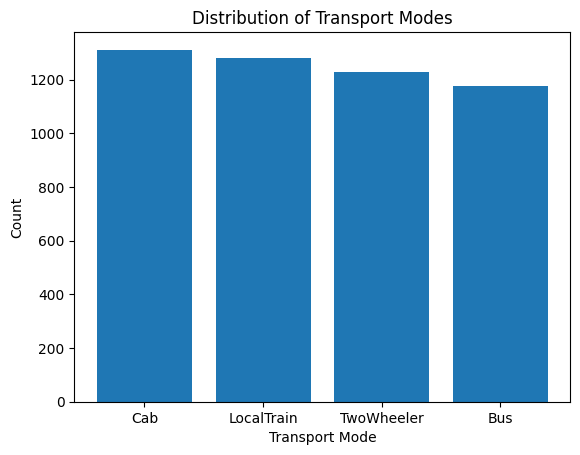

In [16]:
# Count occurrences of each TransportMode and visualize with a bar chart
# value_counts() returns a Series with unique values and their frequencies
s1 = df.TransportMode.value_counts()

# Create bar chart: x-axis = transport modes, y-axis = counts
plt.bar(s1.index, s1.values)
plt.xlabel('Transport Mode')
plt.ylabel('Count')
plt.title('Distribution of Transport Modes')
plt.show()

In [17]:
s1

TransportMode
Cab           1312
LocalTrain    1281
TwoWheeler    1230
Bus           1177
Name: count, dtype: int64

In [18]:
# calculate proportions (relative frequencies) for each TransportMode
# reset index to convert Series to DataFrame for easier manipulation
df2 = df.TransportMode.value_counts().reset_index()

# Sort by count in descending order
df2 = df2.sort_values('count', ascending=False)

# Calculate proportion: count / total count
df2['prop'] = df2['count'] / sum(df2['count'])

print(df2)

  TransportMode  count    prop
0           Cab   1312  0.2624
1    LocalTrain   1281  0.2562
2    TwoWheeler   1230  0.2460
3           Bus   1177  0.2354


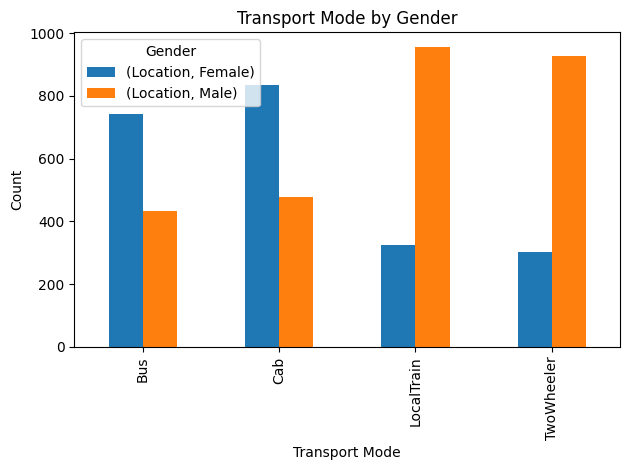

In [19]:
# pivot_table creates a cross-tabulation (counts) of TransportMode vs Gender

df.pivot_table(columns='Gender', index='TransportMode', aggfunc=np.size).plot(kind='bar')
plt.ylabel('Count')
plt.title('Transport Mode by Gender')
plt.xlabel('Transport Mode')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

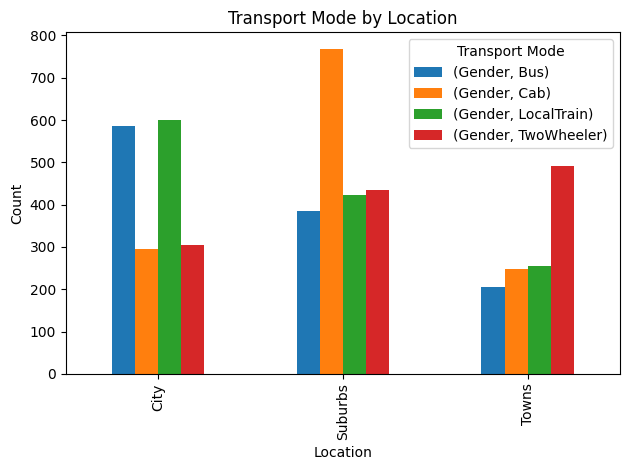

In [20]:
# Create a grouped bar chart: Location by TransportMode
# This shows which transport modes are used in each location
df.pivot_table(columns='TransportMode', index='Location', aggfunc=np.size).plot(kind='bar')
plt.ylabel('Count')
plt.title('Transport Mode by Location')
plt.xlabel('Location')
plt.legend(title='Transport Mode')
plt.tight_layout()
plt.show()

---

#### 3. Handling Missing Data

### Strategies for Missing Data:

1. **Numeric columns**: Fill with mean, median, or mode
2. **Categorical columns**: Fill with mode OR maintain original proportions

We'll demonstrate **proportion-based filling** for categorical data.

In [21]:
# Load dataset with missing values
df = pd.read_excel('data/Responses.xlsx')
df.head()

,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,NaN,NaN,Software,38.0,26.0
2,NaN,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


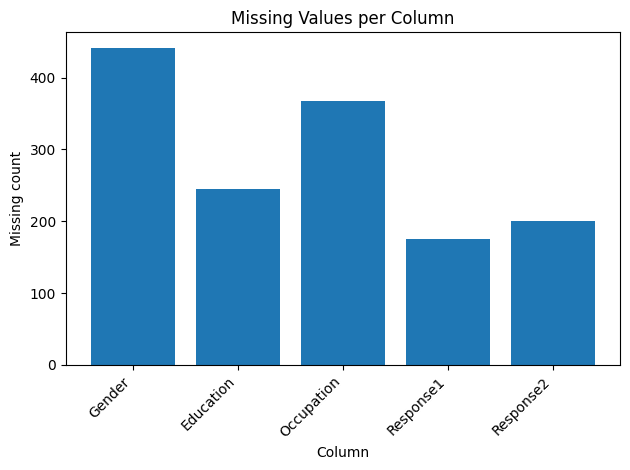

In [22]:
# Visualize missing values count for each column
# isnull().sum() counts NaN values per column
n = df.isnull().sum().reset_index()
n.columns = ['Column', 'Missing_Count']

# Create bar chart showing missing values
plt.bar(n['Column'], n['Missing_Count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing count')
plt.xlabel('Column')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [23]:
# Check current distribution of Gender (before filling NaNs)
print("Gender distribution (before filling):")
print(df.Gender.value_counts(normalize=True))

Gender distribution (before filling):
Gender
Male      0.509761
Female    0.490239
Name: proportion, dtype: float64


### Fill Missing Values with Same Proportions

Instead of filling all NaNs with a single value (like mode), we'll **randomly assign** values based on the existing distribution. This preserves the original proportions in the data.

In [24]:
# Calculate proportions for non-NaN values in Gender column
# normalize=True gives proportions instead of counts
probs = df['Gender'].value_counts(normalize=True)
print("Current proportions:")
print(probs)

Current proportions:
Gender
Male      0.509761
Female    0.490239
Name: proportion, dtype: float64


In [25]:
# Find all row indices where Gender is NaN
nan_idx = df['Gender'][df['Gender'].isna()].index
print(f"Number of missing Gender values: {len(nan_idx)}")

Number of missing Gender values: 441


In [26]:
# Randomly assign 'Male' or 'Female' to NaN values
# based on the observed proportions in the data
# np.random.choice samples from probs.index with probabilities from probs.values
df.loc[nan_idx, 'Gender'] = np.random.choice(
    probs.index,           # ['Male', 'Female']
    size=len(nan_idx),     # Number of NaNs to fill
    p=probs.values         # Probabilities for each gender
)

print("\nGender distribution (after filling):")
print(df.Gender.value_counts(normalize=True))


Gender distribution (after filling):
Gender
Male      0.5094
Female    0.4906
Name: proportion, dtype: float64


---

#### 4. Boxplot for Grouped Data

We can use boxplots to compare distributions across different categories.

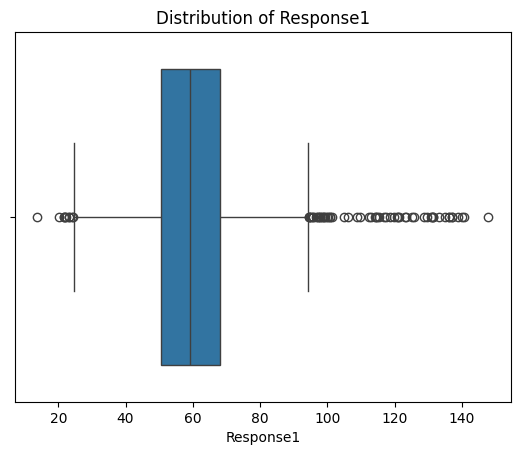

In [27]:
# Single boxplot for Response1 (shows overall distribution)
sns.boxplot(x=df.Response1)
plt.title('Distribution of Response1')
plt.show()

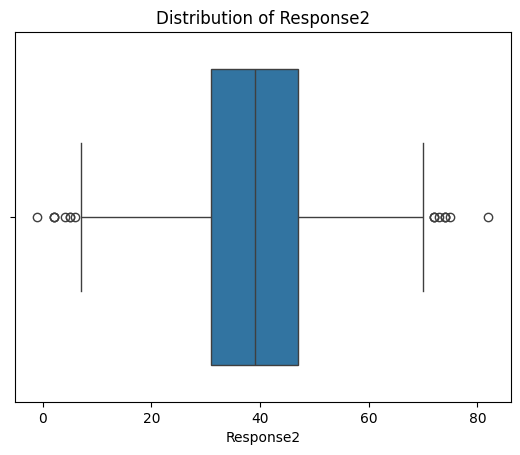

In [28]:
# Single boxplot for Response2
sns.boxplot(x=df.Response2)
plt.title('Distribution of Response2')
plt.show()

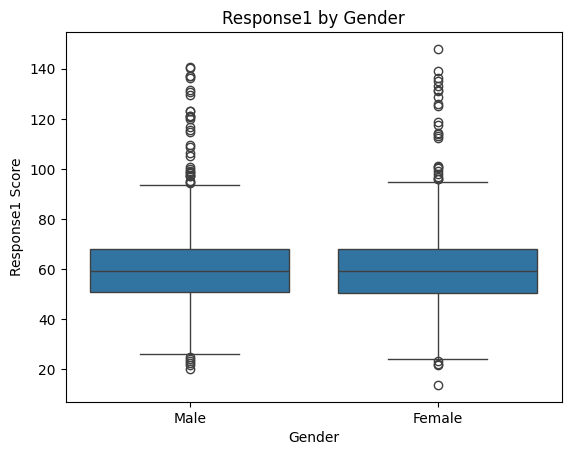

In [29]:
# Grouped boxplot: Compare Response1 distribution for Male vs Female
# x = categorical variable (Gender), y = numeric variable (Response1)
# This shows if Response1 differs between genders
sns.boxplot(x=df.Gender, y=df.Response1)
plt.title('Response1 by Gender')
plt.ylabel('Response1 Score')
plt.show()

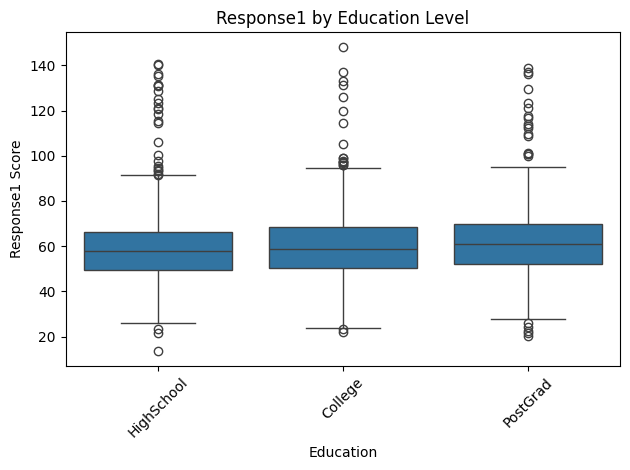

In [30]:
# Grouped boxplot: Compare Response1 distribution across Education levels
sns.boxplot(x=df.Education, y=df.Response1)
plt.title('Response1 by Education Level')
plt.ylabel('Response1 Score')
plt.xlabel('Education')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

### PROBABLITY AND STATS

#### Discrete vs Continuous Variables 

| Feature | Discrete Variable | Continuous Variable |
|---------|-------------------|---------------------|
| Meaning | Countable values | Measurable values |
| Possible values | Finite or countably infinite | Infinite in any range |
| Decimals | ❌ Not allowed | ✔ Allowed |
| Nature | Whole numbers | Fractions/decimals possible |
| How obtained | Counting | Measuring |
| Examples | # of students, # of cars, goals scored, dice outcomes | Height, weight, temperature, time, speed |
| Typical distributions | Binomial, Poisson | Normal, Exponential, Uniform |
| Statistics impact | Uses frequencies, bar, historgram plots | Uses density curves, line graphs |
| Memory trick | `“How many?”` | `“How much?”` |

<img src="https://iili.io/fCfkOXI.md.png" style="max-width:70%;">


---

#### 5. Probability Theory & Distributions

Probability distributions describe how values of a random variable are distributed.

### Types:

1. **Discrete Distributions** (for count data):
   - Binomial
   - Poisson

2. **Continuous Distributions** (for measured data):
   - Normal (Gaussian)
   - Exponential

---

#### 6. Binomial Distribution
<a href="https://iili.io/fCfy8dJ.png" target="_blank">
  <img src="https://iili.io/fCfy8dJ.png" alt="Boxplot Full Size" style="max-width:50%;">
</a>

---

#### Example: Probability of Rain

Suppose the probability that it rains on a given day is   **p = 0.3** (so **q = 1 - p = 0.7**). 


If you observe the weather for **n = 10** days, let **X** be the number of days it rains.

- **p** = Probability of rain on a day = 0.3  
- **q** = Probability of no rain on a day = 1 - 0.3 = 0.7

**Mean (Expected Value):**
$$
\text{Mean} = np = 10 \times 0.3 = 3
$$

**Standard Deviation:**
$$
\text{Standard Deviation} = \sqrt{npq} = \sqrt{10 \times 0.3 \times 0.7} \approx 1.449
$$
---
### When to Use:
- **Binary outcomes** (success/failure, yes/no, heads/tails)
- Fixed number of independent trials
- Constant probability of success

### Formula:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Where:
- $n$ = number of trials
- $k$ = number of successes
- $p$ = probability of success

### Key Functions:
- `binom.pmf(k, n, p)`: Probability of exactly k successes
- `binom.cdf(k, n, p)`: Probability of k or fewer successes
- `binom.sf(k, n, p)`: Probability of more than k successes (survival function)



| Function | What it does | When to use |
|----------|--------------|-------------|
| **pmf**  | Probability Mass Function: Gives probability of a discrete variable taking an exact value | For discrete distributions (e.g., binomial, Poisson) to find P(X = k) |
| **pdf**  | Probability Density Function: Gives relative likelihood of a value for continuous variables (not actual probability at a point) | For continuous distributions (e.g., normal, exponential) to get density at x |
| **cdf**  | Cumulative Distribution Function: Probability that variable is less than or equal to a value (P(X ≤ x)) | To find probability up to a value (area to the left) |
| **sf**   | Survival Function: Probability that variable is greater than a value (P(X > x)), i.e., 1 - CDF | To find probability above a value (area to the right) |
| **ppf**  | Percent Point Function (Inverse CDF): Finds the value for a given cumulative probability | To get the value at a given percentile/quantile |
| **isf**  | Inverse Survival Function: Finds the value for a given upper-tail probability | To get the value at a given upper-tail percentile |

### Example:
"In 15 coin flips with 60% probability of heads, what's the probability of getting exactly 10 heads?"

In [31]:
# Binomial PMF (Probability Mass Function)
# P(X = 10) when n=15, p=0.6
# Question: What's the probability of exactly 10 successes in 15 trials?
prob_exactly_10 = binom.pmf(10, 15, 0.6)
print(f"P(X = 10): {prob_exactly_10:.4f}")

P(X = 10): 0.1859


In [32]:
# Binomial CDF (Cumulative Distribution Function)
# P(X ≤ 10) when n=15, p=0.6
# Question: What's the probability of 10 or fewer successes?
prob_up_to_10 = binom.cdf(10, 15, 0.6)
print(f"P(X ≤ 10): {prob_up_to_10:.4f}")

P(X ≤ 10): 0.7827


In [33]:
# P(X > 9) = 1 - P(X ≤ 9)
# Question: What's the probability of MORE than 9 successes?
prob_more_than_9 = 1 - binom.cdf(9, 15, 0.6)
print(f"P(X > 9) = 1 - P(X ≤ 9): {prob_more_than_9:.4f}")

P(X > 9) = 1 - P(X ≤ 9): 0.4032


In [34]:
# Alternative: Using Survival Function (SF)
# binom.sf(k, n, p) = P(X > k) = 1 - P(X ≤ k)
prob_more_than_9_sf = binom.sf(9, 15, 0.6)
print(f"P(X > 9) using SF: {prob_more_than_9_sf:.4f}")

P(X > 9) using SF: 0.4032


In [35]:
# P(3 ≤ X ≤ 8) = P(X ≤ 8) - P(X ≤ 2)
# Question: What's the probability of getting between 3 and 8 successes (inclusive)?
prob_between_3_and_8 = binom.cdf(8, 15, 0.6) - binom.cdf(2, 15, 0.6)
print(f"P(3 ≤ X ≤ 8): {prob_between_3_and_8:.4f}")

P(3 ≤ X ≤ 8): 0.3899


In [36]:
prob_between_3_and_8 = binom.cdf(30, 70, 0.2) - binom.cdf(9, 70, 0.2)
prob_between_3_and_8 

np.float64(0.9154609748998225)

---

### Poisson Distribution
<img src="https://iili.io/fCquByl.png" alt="Boxplot Full Size" style="max-width:55%;">

### When to Use:
- Counting **rare events** in a fixed interval (time, space, volume)
- Events occur independently
- Known average rate (λ)

### Formula:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

Where:
- $\lambda$ = average rate (mean number of events)
- $k$ = number of events
- $e$ ≈ 2.71828

### Examples:
- Number of calls to a call center per hour
- Number of defects in a production batch
- Number of arrivals at a service point

### Key Functions:
- `poisson.pmf(k, λ)`: Probability of exactly k events
- `poisson.cdf(k, λ)`: Probability of k or fewer events

In [37]:
# Poisson PMF = (probablity mass function)

# Question: If average is 50 events, what's the probability of exactly 45 events?

prob_exactly_45 = poisson.pmf(45, 50)
print(f"P(X = 45) when λ=50: {prob_exactly_45:.4f}")

P(X = 45) when λ=50: 0.0458


In [38]:
# Poisson CDF = (cumulative distribution function)

# Question: What's the probability of 45 or fewer events when average is 50?

prob_up_to_45 = poisson.cdf(45, 50)
print(f"P(X ≤ 45) when λ=50: {prob_up_to_45:.4f}")

P(X ≤ 45) when λ=50: 0.2669


In [39]:
# P(X > 44) = 1 - P(X ≤ 44)
# Question: What's the probability of MORE than 44 events?
prob_more_than_44 = 1 - poisson.cdf(44, 50)
print(f"P(X > 44) when λ=50: {prob_more_than_44:.4f}")

P(X > 44) when λ=50: 0.7790


---

### Exponential Distribution

### When to Use:
- Modeling **time between events** in a Poisson process
- Waiting times, lifetimes, durations

### Formula:

$$f(x) = \frac{1}{\beta} e^{-x/\beta}$$

Where:
- $\beta$ = scale parameter (mean)
- $x$ = time/duration

### Examples:
- Time until next customer arrival
- Lifetime of electronic components
- Time between phone calls

### Key Functions:
- `expon.cdf(x, scale=β)`: P(X ≤ x)
- `expon.ppf(q, scale=β)`: Inverse CDF (quantile function)

In [40]:
# Exponential CDF
# Question: If average time is 43.8 mins, what's the probability
# that an event occurs within 100 minutes?
prob_within_100 = expon.cdf(100, scale=43.8)
print(f"P(X ≤ 100) when mean=43.8: {prob_within_100:.4f}")

P(X ≤ 100) when mean=43.8: 0.8980


In [41]:
# P(X > 100) = 1 - P(X ≤ 100)
# Question: What's the probability that it takes MORE than 100 minutes?
prob_more_than_100 = 1 - expon.cdf(100, scale=43.8)
print(f"P(X > 100) when mean=43.8: {prob_more_than_100:.4f}")

P(X > 100) when mean=43.8: 0.1020


In [42]:
# Exponential PPF (Percent Point Function / Inverse CDF)
# Question: What time corresponds to the 60th percentile?
# (60% of events occur before this time)
time_60th_percentile = expon.ppf(0.6, scale=43.8)
print(f"60th percentile time: {time_60th_percentile:.2f} minutes")

60th percentile time: 40.13 minutes


In [43]:
# Question: What time corresponds to the 99th percentile?
# (99% of events occur before this time)
time_99th_percentile = expon.ppf(0.99, scale=43.8)
print(f"99th percentile time: {time_99th_percentile:.2f} minutes")

99th percentile time: 201.71 minutes


---

### Normal Distribution (Gaussian)

### When to Use:
- **Most important** continuous distribution
- Models many natural phenomena (heights, weights, test scores)
- Central Limit Theorem: means of samples tend to be normally distributed

#### Properties:
- Bell-shaped, symmetric curve
- Completely defined by **mean (μ)** and **standard deviation (σ)**
- 68-95-99.7 rule:
  - 68% of data within μ ± σ
  - 95% of data within μ ± 2σ
  - 99.7% of data within μ ± 3σ

<img src="https://www.scribbr.de/wp-content/uploads/2023/01/standard-normal-distribution-example.webp" alt="Normal Distribution" style="width: 800px;"/>

#### Z-Score:

$$z = \frac{x - \mu}{\sigma}$$

Converts any normal distribution to **standard normal** (μ=0, σ=1)

##### Key Functions:
- `norm.cdf(x, μ, σ)`: P(X ≤ x)
- `norm.ppf(q, μ, σ)`: Inverse CDF (find x for given probability q)

### Example Problem:

**Scenario**: Travel time from Mumbai to Kolhapur
- Average time (μ) = 5 hours
- Standard deviation (σ) = 1.3 hours

In [44]:
# Question: What is the probability of completing the trip in LESS than 4.5 hours?
# P(X < 4.5) when μ=5, σ=1.3
prob_less_than_4_5 = norm.cdf(4.5, 5, 1.3)
print(f"P(X < 4.5 hours): {prob_less_than_4_5:.4f}")

P(X < 4.5 hours): 0.3503


In [45]:
# Question: What is the probability of taking MORE than 4.5 hours?
# P(X > 4.5) = 1 - P(X ≤ 4.5)
prob_more_than_4_5 = 1 - norm.cdf(4.5, 5, 1.3)
print(f"P(X > 4.5 hours): {prob_more_than_4_5:.4f}")

P(X > 4.5 hours): 0.6497


In [46]:
# Question: What is the probability of taking between 4.2 and 5.3 hours?
# P(4.2 < X < 5.3) = P(X ≤ 5.3) - P(X ≤ 4.2)
prob_between = norm.cdf(5.3, 5, 1.3) - norm.cdf(4.2, 5, 1.3)
print(f"P(4.2 < X < 5.3 hours): {prob_between:.4f}")

P(4.2 < X < 5.3 hours): 0.3221


In [47]:
# Question: Below what time are 65% of trips completed?
# Find the 65th percentile (x such that P(X ≤ x) = 0.65)
time_65th = norm.ppf(0.65, 5, 1.3)
print(f"65% of trips are completed in less than {time_65th:.2f} hours")

65% of trips are completed in less than 5.50 hours


#### Z-Score

Z-score tells you **how far a value is from the mean**, measured in units of standard deviation.  
It answers:  
**"How unusual or typical is this value compared to the rest of the data?"**

---

#### What a Z-Score Really Means

- A z-score of **0** means the value is exactly at the mean.  
- A **positive** z-score means the value is above the mean.  
- A **negative** z-score means the value is below the mean.  
- A **large absolute value** (like > 2 or > 3) means the value is far from the mean and may be an outlier.

Z-score converts raw data into a standardized scale so values from different units or ranges can be compared fairly.

---

#### Z-Score Formula

$$
z = \frac{x - \mu}{\sigma}
$$

- x = the value  
- μ = mean of the dataset  
- σ = standard deviation   

---

#### Why Z-Scores Are Used

##### 1. Standardizing different units  
Raw values might be in different units, like height (cm) and weight (kg).  
Z-scores place them on the same scale.

##### 2. Detecting outliers  
Values with very high or very low z-scores indicate unusual or extreme data points.

##### 3. Probability and normal distribution  
Z-scores map your data onto the standard normal distribution, allowing probability calculations.

##### 4. Machine learning  
Many algorithms expect data to be standardized (mean = 0, std = 1).

---

#### Simple Example

Dataset mean = 14  
Standard deviation = 2.83  
Value = 18

$$
z = \frac{18 - 14}{2.83} \approx 1.41
$$

Interpretation:  
The value 18 is **1.41 standard deviations above the mean**.  
It is slightly higher than average, but not extreme.

---

#### In short

A z-score is a measure that shows **how far a value is from the mean**, using standard deviation as the ruler.  
It tells you whether the value is low, high, or extremely different compared to the rest of the dataset.

In [48]:
# Calculate Z-score for x = 4.5 when μ=5, σ=1.3
# Calculate Z-score manually
x = 4.5          # the VALUE
mu = 5           # MEAN of dataset
sigma = 1.3      # STD

z = (x - mu) / sigma

print(f"Z-score for x = {x}: {z:.4f}")

Z-score for x = 4.5: -0.3846


In [49]:
# For STANDARD NORMAL distribution (μ=0, σ=1):
# We can use the Z-score directly
# P(Z ≤ z) gives the same probability as P(X ≤ 4.5) in original distribution
prob_standard = norm.cdf(z)  # No need to specify μ and σ (defaults: 0, 1)
print(f"P(Z ≤ {z:.4f}) in standard normal: {prob_standard:.4f}")
print(f"This matches our earlier result: {prob_less_than_4_5:.4f}")

P(Z ≤ -0.3846) in standard normal: 0.3503
This matches our earlier result: 0.3503


---

### Summary

### Descriptive Statistics:
- **Boxplot**: Visualize distribution, identify outliers using IQR method
- **Quartiles**: Q1, Q2 (median), Q3 divide data into quarters
- **Outliers**: Values beyond Q1 - 1.5×IQR or Q3 + 1.5×IQR

### Probability Distributions:

| Distribution | Type | Use Case | Parameters |
|-------------|------|----------|------------|
| **Binomial** | Discrete | Fixed trials, binary outcome | n, p |
| **Poisson** | Discrete | Rare events, known rate | λ |
| **Exponential** | Continuous | Time between events | β (scale) |
| **Normal** | Continuous | Natural phenomena, measurements | μ, σ |

### Key Functions:
- **PMF/PDF**: Probability at a specific value
- **CDF**: Cumulative probability (P(X ≤ x))
- **PPF**: Inverse CDF (find x for given probability)
- **SF**: Survival function (P(X > x) = 1 - CDF)

---

---

### student's t-distribution

### when to use:
- **small sample sizes** (typically n < 30)
- **unknown population standard deviation**
- estimating population mean from sample data
- similar to normal distribution but with heavier tails (accounts for uncertainty)

### properties:
- bell-shaped and symmetric like normal distribution
- controlled by **degrees of freedom (df)** = n - 1
- as sample size increases, t-distribution approaches normal distribution
- heavier tails than normal (more probability in extremes)

### formula for t-statistic:

$$t = \frac{\bar{x} - \mu}{s / \sqrt{n}}$$

where:
- x̄ = sample mean
- μ = hypothesized population mean
- s = sample standard deviation
- n = sample size

### key functions:
- `t.cdf(x, df)`: P(T ≤ x) with given degrees of freedom
- `t.ppf(q, df)`: inverse cdf (find t-value for given probability)
- `t.pdf(x, df)`: probability density at x

---

### quick reference: when to use which distribution

#### **binomial**
- count successes in fixed number of independent trials with constant probability
- example: 10 coin flips, how many heads?
- **key:** probability is given and expects 2 outcomes (success/failure)

#### **poisson**
- count rare events in fixed interval of time/space
- example: number of emails received per hour, typos in entire newspaper
- **key:** when probability is not given (when probability is small, we do frequency counts instead)

#### **exponential**
- time between events in a poisson process
- example: wait time until next customer arrives, time between horn blows during 2-hour class
- **key:** monitoring the time between 2 events

#### **normal**
- model continuous data that clusters around a mean
- example: heights of adults, measurement errors
- **key:** both mean and std are given, but sample size isn't given

#### **student's t**
- estimate population mean with small sample size when standard deviation is unknown
- example: average test scores from 15 students
- **key:** sample size is given (usually under 30), degrees of freedom = sample size - 1

---

### quick reference: distribution functions

#### **pmf (probability mass function)**
- used to find exact discrete value
- applies to: binomial, poisson
- example: exactly 5 heads in 10 flips

#### **cdf (cumulative distribution function)**
- gives the total probability up to a particular number
- applies to: all distributions
- example: at most 5 heads, probability ≤ x

#### **sf (survival function) or 1 - cdf**
- probability greater than a particular number
- applies to: all distributions
- example: more than 5 heads, probability > x

#### **ppf (percent point function)**
- gives the value at a given percentile (left of the probability)
- inverse of cdf
- applies to: all distributions
- example: what value has 95% of data below it?

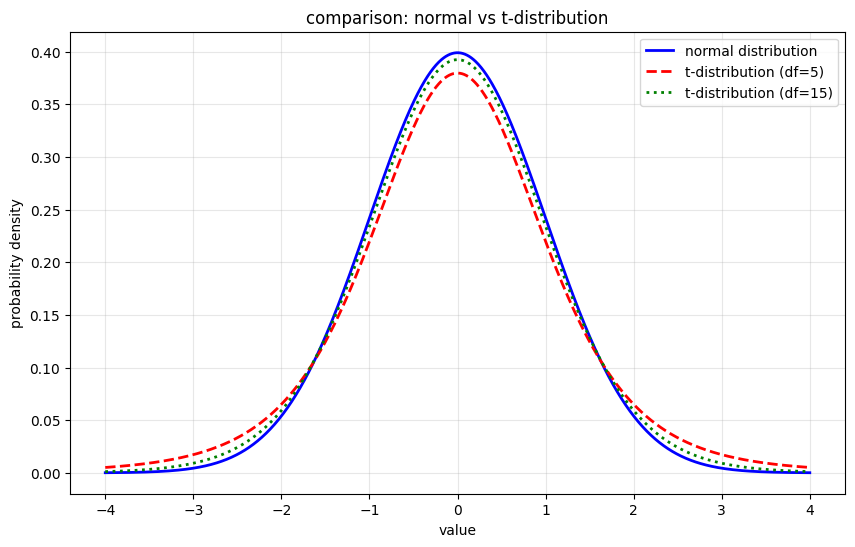

notice: as degrees of freedom increase, t-distribution approaches normal distribution


In [50]:
# visualize t-distribution vs normal distribution
x = np.linspace(-4, 4, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, norm.pdf(x), 'b-', linewidth=2, label='normal distribution')
plt.plot(x, t.pdf(x, df=5), 'r--', linewidth=2, label='t-distribution (df=5)')
plt.plot(x, t.pdf(x, df=15), 'g:', linewidth=2, label='t-distribution (df=15)')
plt.xlabel('value')
plt.ylabel('probability density')
plt.title('comparison: normal vs t-distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("notice: as degrees of freedom increase, t-distribution approaches normal distribution")

In [51]:
# question: what t-value corresponds to 95% confidence (two-tailed)?
# for 95% confidence, we need 2.5% in each tail
# so we find the 97.5th percentile

t_critical = t.ppf(0.975, df)
print(f"t-critical value (95% confidence, df={df}): {t_critical:.4f}")
print(f"\ninterpretation: for 95% confidence interval with {n} samples,")
print(f"we use ± {t_critical:.4f} standard errors around the mean")

TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:
# example: test scores from 15 students
# sample mean = 75, sample std = 8, hypothesized mean = 70

n = 15
sample_mean = 75
sample_std = 8
hypothesized_mean = 70
df = n - 1  # degrees of freedom

# calculate t-statistic
t_stat = (sample_mean - hypothesized_mean) / (sample_std / np.sqrt(n))
print(f"sample size: {n}")
print(f"degrees of freedom: {df}")
print(f"t-statistic: {t_stat:.4f}")

# find probability (p-value for two-tailed test)
p_value = 2 * (1 - t.cdf(abs(t_stat), df))
print(f"p-value (two-tailed): {p_value:.4f}")